In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 

### Loading of dataset

In [3]:
df= pd.read_csv("C:/Users/ADMIN/OneDrive/Desktop/ML Tasks/onlinefoods.xlsx - onlinefoods.csv", header =0)

### Initial Preprocessing #

In [5]:
df.describe()

,Age,Family size,Pin code
count,388.000000,388.000000,388.000000
mean,24.628866,3.280928,560040.113402
std,2.975593,1.351025,31.399609
min,18.000000,1.000000,560001.000000
25%,23.000000,2.000000,560010.750000
50%,24.000000,3.000000,560033.500000
75%,26.000000,4.000000,560068.000000
max,33.000000,6.000000,560109.000000


In [6]:
df.head()

,Age,Gender,Marital Status,Occupation,Educational Qualifications,Family size,Pin code,Feedback
0,20,Female,Single,Student,Post Graduate,4,560001,Positive
1,24,Female,Single,Student,Graduate,3,560009,Positive
2,22,Male,Single,Student,Post Graduate,3,560017,Negative
3,22,Female,Single,Student,Graduate,6,560019,Positive
4,22,Male,Single,Student,Post Graduate,4,560010,Positive


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 388 entries, 0 to 387
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Age                         388 non-null    int64 
 1   Gender                      388 non-null    object
 2   Marital Status              388 non-null    object
 3   Occupation                  388 non-null    object
 4   Educational Qualifications  388 non-null    object
 5   Family size                 388 non-null    int64 
 6   Pin code                    388 non-null    int64 
 7   Feedback                    388 non-null    object
dtypes: int64(3), object(5)
memory usage: 24.4+ KB


### Filling the missing values for both numeric and categorical data 

In [9]:
# Separate numerical and categorical columns
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Log the number of missing values before imputation
print("Missing values before imputation:")
print(df.isnull().sum())

# Fill missing numerical values with the median
df[numerical_cols] = df[numerical_cols].apply(lambda x: x.fillna(x.median()), axis=0)

# Fill missing categorical values with the mode
for col in categorical_cols:
    if df[col].isnull().sum() > 0:  # Check if missing values exist
        df[col] = df[col].fillna(df[col].mode()[0])

# Log the number of missing values after imputation
print("\nMissing values after imputation:")
print(df.isnull().sum())

Missing values before imputation:
Age                           0
Gender                        0
Marital Status                0
Occupation                    0
Educational Qualifications    0
Family size                   0
Pin code                      0
Feedback                      0
dtype: int64

Missing values after imputation:
Age                           0
Gender                        0
Marital Status                0
Occupation                    0
Educational Qualifications    0
Family size                   0
Pin code                      0
Feedback                      0
dtype: int64


### Apply one-hot encoding to the categorical variables

In [11]:
# Apply One-Hot Encoding
catg_col = ['Gender', 'Marital Status', 'Occupation', 'Educational Qualifications', 'Feedback'] 
df = pd.get_dummies(df, columns = catg_col, drop_first=True)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 388 entries, 0 to 387
Data columns (total 10 columns):
 #   Column                                    Non-Null Count  Dtype
---  ------                                    --------------  -----
 0   Age                                       388 non-null    int64
 1   Family size                               388 non-null    int64
 2   Pin code                                  388 non-null    int64
 3   Gender_Male                               388 non-null    bool 
 4   Marital Status_Prefer not to say          388 non-null    bool 
 5   Marital Status_Single                     388 non-null    bool 
 6   Occupation_Student                        388 non-null    bool 
 7   Educational Qualifications_Post Graduate  388 non-null    bool 
 8   Educational Qualifications_Uneducated     388 non-null    bool 
 9   Feedback_Positive                         388 non-null    bool 
dtypes: bool(7), int64(3)
memory usage: 11.9 KB


In [13]:
df.head()

,Age,Family size,Pin code,Gender_Male,Marital Status_Prefer not to say,Marital Status_Single,Occupation_Student,Educational Qualifications_Post Graduate,Educational Qualifications_Uneducated,Feedback_Positive
0,20,4,560001,False,False,True,True,True,False,True
1,24,3,560009,False,False,True,True,False,False,True
2,22,3,560017,True,False,True,True,True,False,False
3,22,6,560019,False,False,True,True,False,False,True
4,22,4,560010,True,False,True,True,True,False,True


In [14]:
df.shape

(388, 10)

### Checking for outliers

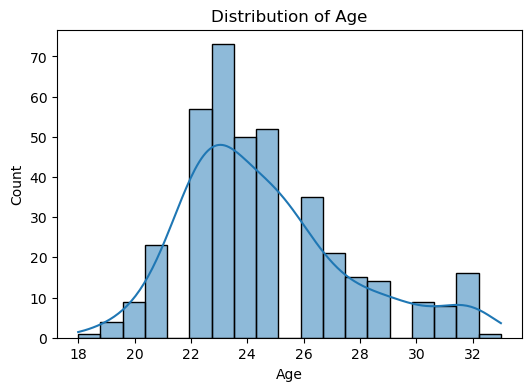

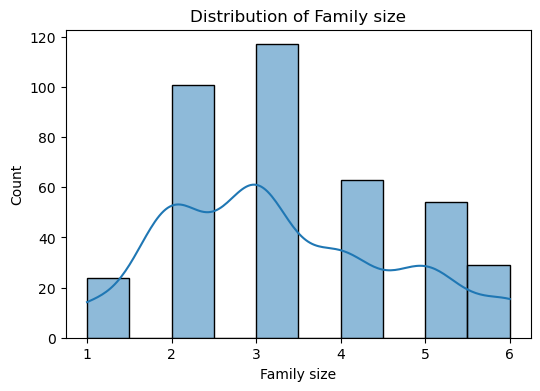

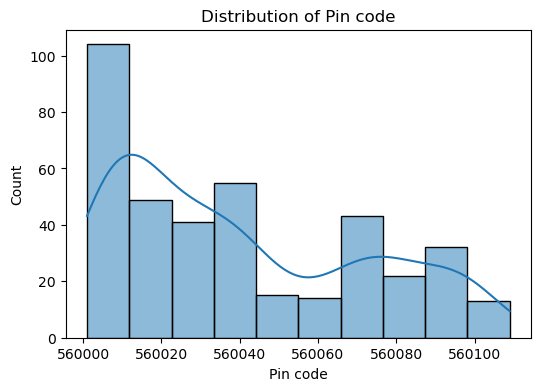

In [16]:
# Plotting histogram for numerical columns
numerical_cols = ['Age', 'Family size', 'Pin code']

for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)  # kde=True will add a Kernel Density Estimation line to show the distribution
    plt.title(f'Distribution of {col}')
    plt.show()

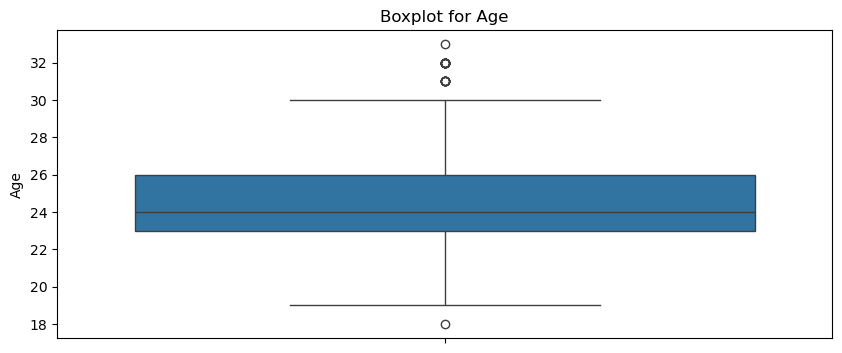

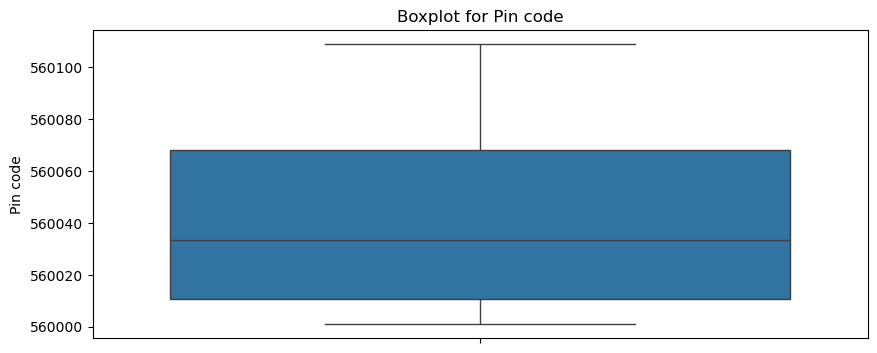

Number of outliers in each column before removal:
Age            26
Family size     0
Pin code        0
dtype: int64

Shape of dataset before outlier removal: (388, 10)
Shape of dataset after outlier removal: (362, 10)


In [17]:
# Visualize outliers using boxplots for numerical columns
for col in df.select_dtypes(include=['float64', 'int64']).columns:
    if df[col].nunique() > 10:  # Avoid boxplots for columns with few unique values
        plt.figure(figsize=(10, 4))
        sns.boxplot(df[col])
        plt.title(f"Boxplot for {col}")
        plt.show()

# Handling outliers using the IQR method
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Calculate Q1 (25th percentile) and Q3 (75th percentile) for numerical columns
Q1 = df[numerical_cols].quantile(0.25)
Q3 = df[numerical_cols].quantile(0.75)
IQR = Q3 - Q1

# Log outliers before removing them
outliers = ((df[numerical_cols] < (Q1 - 1.5 * IQR)) | (df[numerical_cols] > (Q3 + 1.5 * IQR))).sum()
print("Number of outliers in each column before removal:")
print(outliers)

# Remove outliers based on the IQR method
df_clean = df[~((df[numerical_cols] < (Q1 - 1.5 * IQR)) | (df[numerical_cols] > (Q3 + 1.5 * IQR))).any(axis=1)]

# Log the shape of the dataset before and after outlier removal
print(f"\nShape of dataset before outlier removal: {df.shape}")
print(f"Shape of dataset after outlier removal: {df_clean.shape}")

In [18]:
# Calculate skewness for each numerical column
skewness = df[numerical_cols].skew()
print(skewness)

Age            0.809877
Family size    0.401376
Pin code       0.574913
dtype: float64


In [19]:
df.corr()

,Age,Family size,Pin code,Gender_Male,Marital Status_Prefer not to say,Marital Status_Single,Occupation_Student,Educational Qualifications_Post Graduate,Educational Qualifications_Uneducated,Feedback_Positive
Age,1.000000,0.169982,0.137294,0.062038,0.127512,-0.665257,-0.567099,-0.100419,0.154321,-0.198170
Family size,0.169982,1.000000,-0.009402,-0.082488,-0.092363,-0.183034,-0.048757,-0.050979,0.011687,-0.010148
Pin code,0.137294,-0.009402,1.000000,0.035685,0.025464,-0.100893,-0.173465,-0.080938,-0.049611,-0.003603
Gender_Male,0.062038,-0.082488,0.035685,1.000000,0.004033,0.029977,-0.090050,-0.090822,-0.010499,-0.045486
Marital Status_Prefer not to say,0.127512,-0.092363,0.025464,0.004033,1.000000,-0.266977,-0.170230,0.027015,-0.012859,-0.107966
Marital Status_Single,-0.665257,-0.183034,-0.100893,0.029977,-0.266977,1.000000,0.581496,0.177656,-0.107572,0.202498
Occupation_Student,-0.567099,-0.048757,-0.173465,-0.090050,-0.170230,0.581496,1.000000,0.210973,-0.008216,0.235158
Educational Qualifications_Post Graduate,-0.100419,-0.050979,-0.080938,-0.090822,0.027015,0.177656,0.210973,1.000000,-0.073103,0.147314
Educational Qualifications_Uneducated,0.154321,0.011687,-0.049611,-0.010499,-0.012859,-0.107572,-0.008216,-0.073103,1.000000,-0.059016
Feedback_Positive,-0.198170,-0.010148,-0.003603,-0.045486,-0.107966,0.202498,0.235158,0.147314,-0.059016,1.000000


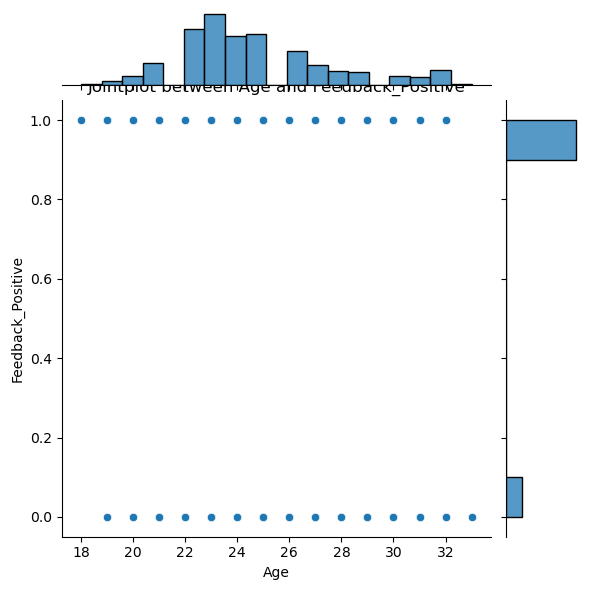

In [20]:
# Jointplot for Age and Feedback_Positive
sns.jointplot(x='Age', y='Feedback_Positive', data=df, kind='scatter', height=6)
plt.title("Jointplot between Age and Feedback_Positive", loc='center')
plt.show()

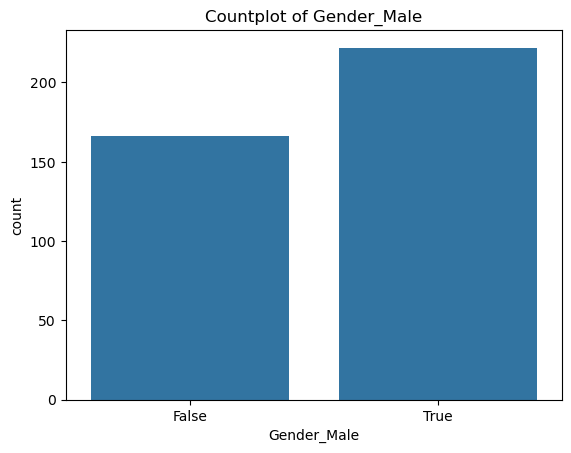

In [21]:
# Countplot for Gender_Male
sns.countplot(x='Gender_Male', data=df)
plt.title("Countplot of Gender_Male")
plt.show()

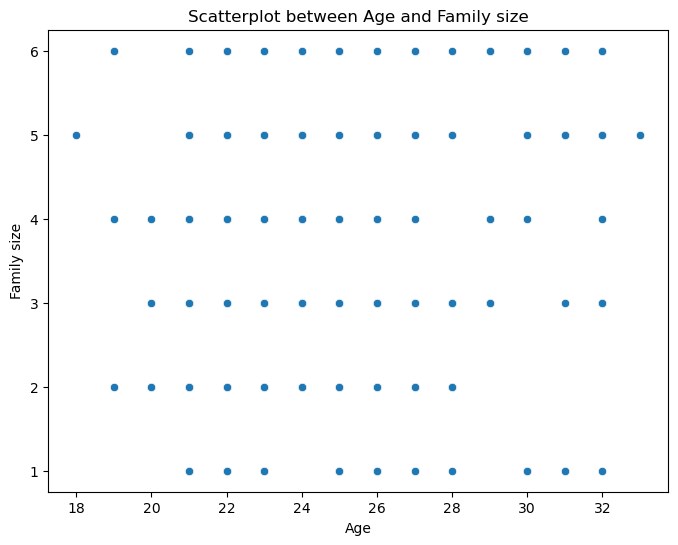

In [22]:
# Scatterplot for Age and Family size
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Age', y='Family size', data=df)
plt.title("Scatterplot between Age and Family size")
plt.show()

### Split Train and Test set

In [24]:
print(df.columns)

Index(['Age', 'Family size', 'Pin code', 'Gender_Male',
       'Marital Status_Prefer not to say', 'Marital Status_Single',
       'Occupation_Student', 'Educational Qualifications_Post Graduate',
       'Educational Qualifications_Uneducated', 'Feedback_Positive'],
      dtype='object')


In [25]:
# Import the necessary library
from sklearn.model_selection import train_test_split

# Features (X) will contain all columns except 'Feedback_Positive', which is the target column
X = df.drop('Feedback_Positive', axis=1)

# Target (y) will be 'Feedback_Positive'
y = df['Feedback_Positive']

# Now split the data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Check the shape of training and test data
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(310, 9) (78, 9) (310,) (78,)


### Importing Train Models

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

logreg = LogisticRegression()
logreg.fit(X_train_scaled, y_train)

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

In [28]:
# Logistic Regression
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)

# Linear Discriminant Analysis
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

# K-Nearest Neighbors
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

# Decision Tree Classifier
dtree = DecisionTreeClassifier()
dtree.fit(X_train, y_train)

DecisionTreeClassifier()

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Define a function to evaluate models and return metrics
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    cm = confusion_matrix(y_test, y_pred)
    
    print(f"\nModel: {model_name}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"Confusion Matrix:\n{cm}")
    
    return {'Model': model_name, 'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 'F1 Score': f1}

In [30]:
# Initialize a list to hold the results
results = []

In [31]:
# Evaluate models
results.append(evaluate_model(logreg, X_test, y_test, "Logistic Regression"))
results.append(evaluate_model(lda, X_test, y_test, "LDA"))
results.append(evaluate_model(knn, X_test, y_test, "KNN"))
results.append(evaluate_model(dtree, X_test, y_test, "Decision Tree"))


Model: Logistic Regression
Accuracy: 0.8590
Precision: 0.7378
Recall: 0.8590
F1 Score: 0.7938
Confusion Matrix:
[[ 0 11]
 [ 0 67]]

Model: LDA
Accuracy: 0.8462
Precision: 0.7363
Recall: 0.8462
F1 Score: 0.7874
Confusion Matrix:
[[ 0 11]
 [ 1 66]]

Model: KNN
Accuracy: 0.8205
Precision: 0.7695
Recall: 0.8205
F1 Score: 0.7907
Confusion Matrix:
[[ 1 10]
 [ 4 63]]

Model: Decision Tree
Accuracy: 0.8077
Precision: 0.8288
Recall: 0.8077
F1 Score: 0.8170
Confusion Matrix:
[[ 5  6]
 [ 9 58]]


In [32]:
# Convert the results to a DataFrame for better visualization
results_df = pd.DataFrame(results)

In [33]:
# Display the results as a table
print("\nPerformance Metrics for All Models:")
print(results_df)


Performance Metrics for All Models:
                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.858974   0.737837  0.858974  0.793811
1                  LDA  0.846154   0.736264  0.846154  0.787393
2                  KNN  0.820513   0.769512  0.820513  0.790705
3        Decision Tree  0.807692   0.828812  0.807692  0.817029


### Decision Tree is considered the best overall model because of 
Accuracy: 0.820
5
Precision: 0.833
9
Recall: 0.82
05
F1 Score: 0.8
266
Confusion Matrix:
[[ 5  6]
 [ 8 59]]

### ---Suhana Bagwan 